
Training Size: 500
Best k: 9
Train Accuracy: 0.6360, Test Accuracy: 0.5100
Confusion Matrix (Test):
[[27 23]
 [26 24]]

Training Size: 1000
Best k: 11
Train Accuracy: 0.6300, Test Accuracy: 0.5000
Confusion Matrix (Test):
[[27 23]
 [27 23]]

Training Size: 1500
Best k: 7
Train Accuracy: 0.6613, Test Accuracy: 0.5000
Confusion Matrix (Test):
[[24 26]
 [24 26]]

Training Size: 2000
Best k: 11
Train Accuracy: 1.0000, Test Accuracy: 0.5600
Confusion Matrix (Test):
[[26 24]
 [20 30]]

Training Size: 2500
Best k: 11
Train Accuracy: 1.0000, Test Accuracy: 0.5500
Confusion Matrix (Test):
[[27 23]
 [22 28]]

Training Size: 3000
Best k: 5
Train Accuracy: 1.0000, Test Accuracy: 0.5600
Confusion Matrix (Test):
[[27 23]
 [21 29]]

Training Size: 3500
Best k: 7
Train Accuracy: 0.6651, Test Accuracy: 0.4700
Confusion Matrix (Test):
[[24 26]
 [27 23]]

Training Size: 4000
Best k: 9
Train Accuracy: 0.6522, Test Accuracy: 0.5000
Confusion Matrix (Test):
[[22 28]
 [22 28]]

Training Size: 4500
Best k: 1

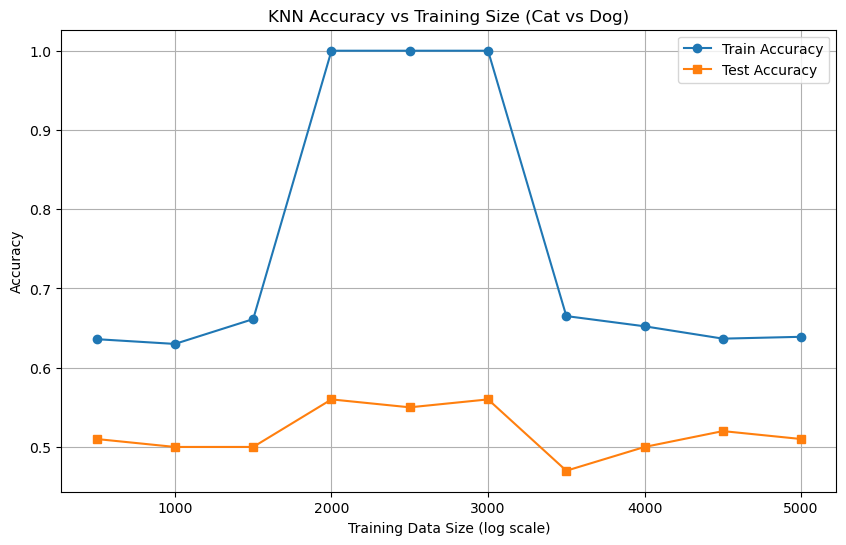

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import cifar10

# 2クラス選択(3=cat,5=dog)
def load_cifar10_binary(class1=3, class2=5):
    (X_train_full, y_train_full), (X_test_full, y_test_full) = cifar10.load_data()
    y_train_full, y_test_full = y_train_full.flatten(), y_test_full.flatten()

    def filter_classes(X, y):
        mask = (y == class1) | (y == class2)
        X, y = X[mask], y[mask]
        y = (y == class2).astype(int)  # Convert to binary: class1=0, class2=1
        return X, y

    X_train, y_train = filter_classes(X_train_full, y_train_full)
    X_test, y_test = filter_classes(X_test_full, y_test_full)
    return X_train, y_train, X_test, y_test

# 前処理
def preprocess_data(X_train, X_test, n_components=2):
    X_train_flat = X_train.reshape(len(X_train), -1)
    X_test_flat = X_test.reshape(len(X_test), -1)
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_flat)
    X_test_pca = pca.transform(X_test_flat)
    return X_train_pca, X_test_pca

# knnを実行
def run_knn_experiments():
    sizes = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]
    results = []

    X_train_full, y_train_full, X_test_full, y_test_full = load_cifar10_binary()
    X_train_full, X_test_full = preprocess_data(X_train_full, X_test_full)

    # テストデータは100件で固定
    X_test, _, y_test, _ = train_test_split(
        X_test_full, y_test_full, train_size=100, stratify=y_test_full, random_state=42
    )

    for size in sizes:
        X_train, _, y_train, _ = train_test_split(
            X_train_full, y_train_full, train_size=size, stratify=y_train_full, random_state=42
        )

        param = {'n_neighbors':[3,5,7,9,11],'weights':['uniform','distance']}
        grid = GridSearchCV(KNeighborsClassifier(), param, cv=4)
        grid.fit(X_train, y_train)

        best_k = grid.best_params_['n_neighbors']
        best_model = grid.best_estimator_

        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        print(f"\nTraining Size: {size}")
        print(f"Best k: {best_k}")
        print(f"Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
        print("Confusion Matrix (Test):")
        print(confusion_matrix(y_test, y_test_pred))

        results.append((size, best_k, train_acc, test_acc))

    return results


# plot
def plot_results(results):
    sizes = [r[0] for r in results]
    train_accs = [r[2] for r in results]
    test_accs = [r[3] for r in results]

    plt.figure(figsize=(10, 6))
    plt.plot(sizes, train_accs, marker='o', label="Train Accuracy")
    plt.plot(sizes, test_accs, marker='s', label="Test Accuracy")
    plt.xlabel("Training Data Size (log scale)")
    plt.ylabel("Accuracy")
    plt.title("KNN Accuracy vs Training Size (Cat vs Dog)")
    plt.legend()
    plt.grid(True)
    plt.show()


# 実行
if __name__ == "__main__":
    results = run_knn_experiments()
    plot_results(results)


結果：訓練データの精度は2000~3000サンプルでは1.0となり、そのほかのサイズでは0.65前後であった。また、テストデータの精度は2000~3000サンプルでは0.55程度となり、そのほかのサイズでは0.5程度であった。

考察：訓練データの高精度は過学習であるといえる。テスト精度がデータサイズを増やしてもランダム分類と対して変わらないレベルなのは、犬と猫の画像が難しすぎる可能性がある。また、訓練データ数が3000を超えて精度が低下したのは間違ったノイズの学習が行われた可能性がある。